In [44]:
import plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
from dataset_hasher import hash_datasets

hash_datasets('../Datasets')


File #1
--------------------------------------------------
  Name:       Celebrity.csv
  Path:       Celebrity.csv
  Size:       607.62 KB (622,202 bytes)
  Created:    2024-07-31 15:41:24
  MD5 Hash:   72884f07e61708a46305712ac4db2268

File #2
--------------------------------------------------
  Name:       actorfilms.csv
  Path:       IMDB/actorfilms.csv
  Size:       11.96 MB (12,538,592 bytes)
  Created:    2021-11-08 15:37:40
  MD5 Hash:   5df9956f6c042db390f1b1484070e1f5

File #3
--------------------------------------------------
  Name:       name.basics.tsv
  Path:       IMDB/name.basics.tsv
  Size:       874.45 MB (916,928,198 bytes)
  Created:    2025-11-09 19:09:07
  MD5 Hash:   f5471dae96edfb1d7f1347b9e23a104f

File #4
--------------------------------------------------
  Name:       title.crew.tsv
  Path:       IMDB/title.crew.tsv
  Size:       378.85 MB (397,253,726 bytes)
  Created:    2025-11-09 19:09:42
  MD5 Hash:   fe13a1710cc90488a0be1b0ce149059f

File #5
----------

In [46]:
import pandas as pd

df_actors = pd.read_csv('../Datasets/IMDB/actorfilms.csv', low_memory=False)
df_actors = df_actors[pd.to_numeric(df_actors['Year'], errors='coerce') >= 1990]

We took this dataset from IMDB. From this we can see in which films actors were in. We can see the actor's id, movie, the year that movie was released, the ratings and the filmid of the movie.

In [47]:
df_actors

,Actor,ActorID,Film,Year,Votes,Rating,FilmID
39,Lauren Bacall,nm0000002,Ernest & Celestine,2012,18793,7.9,tt1816518
40,Lauren Bacall,nm0000002,The Forger,2012,4472,5.4,tt1368858
41,Lauren Bacall,nm0000002,All at Sea,2010,110,5.7,tt0858500
42,Lauren Bacall,nm0000002,The Walker,2007,5256,5.8,tt0783608
43,Lauren Bacall,nm0000002,Manderlay,2005,22622,7.3,tt0342735
...,...,...,...,...,...,...,...
191868,Roman Griffin Davis,nm9877392,Jojo Rabbit,2019,310904,7.9,tt2584384
191869,Lexi Rabe,nm9962642,Silk Road,2021,2050,5.9,tt7937254
191870,Lexi Rabe,nm9962642,Avengers: Endgame,2019,849079,8.4,tt4154796
191871,Lexi Rabe,nm9962642,Godzilla: King of the Monsters,2019,146737,6.0,tt3741700


In [48]:
actors_set = sorted(set(df_actors['Actor'].tolist()))  # Sorted for deterministic iteration

In [49]:
print("We have " +str(len(actors_set)) + " actors in the df_actors dataset.")

We have 9134 actors in the df_actors dataset.


We will cut out actors who had their first movies before 1980, because we wanted to work with more up-to-date actors.

In [50]:
from Artist_Director_Graph.actor_director_functions import cut_off_actors_whose_first_movie_was_before_1980

# cut out actors whose first film was before 1980

actors_after_1980 = cut_off_actors_whose_first_movie_was_before_1980(actors_set, df_actors)

In [51]:
#We will work with this many actors
print(f"We will only work with {len(actors_after_1980)} actors")

We will only work with 9134 actors


This dataframe contains IMDb ids of movie title's with director ids and writer ids. We will only work with the movies and directors from this df_movie_directors dataset.

In [52]:
df_movie_directors = pd.read_csv('../Datasets/IMDB/title.crew.tsv', sep='\t', low_memory=False)

In [53]:
df_movie_directors

,tconst,directors,writers
0,tt0000001,nm0005690,\N
1,tt0000002,nm0721526,\N
2,tt0000003,nm0721526,nm0721526
3,tt0000004,nm0721526,\N
4,tt0000005,nm0005690,\N
...,...,...,...
12048914,tt9916848,nm1485677,"nm9187127,nm1485677,nm9826385,nm9299459,nm1628284"
12048915,tt9916850,nm1485677,"nm9187127,nm1485677,nm9826385,nm1628284"
12048916,tt9916852,nm1485677,"nm9187127,nm1485677,nm9826385,nm9299459,nm1628284"
12048917,tt9916856,nm10538645,nm6951431


This df_name_to_id dataset maps together people ids (e.g. directors, writers, actors) to their names.

In [54]:
df_name_to_id = pd.read_csv('../Datasets/IMDB/name.basics.tsv', sep='\t', low_memory=False)

In [55]:
df_name_to_id

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
0,nm0000001,Fred Astaire,1899,1987,"actor,miscellaneous,producer","tt0072308,tt0050419,tt0027125,tt0025164"
1,nm0000002,Lauren Bacall,1924,2014,"actress,miscellaneous,soundtrack","tt0037382,tt0075213,tt0038355,tt0117057"
2,nm0000003,Brigitte Bardot,1934,\N,"actress,music_department,producer","tt0057345,tt0049189,tt0056404,tt0054452"
3,nm0000004,John Belushi,1949,1982,"actor,writer,music_department","tt0072562,tt0077975,tt0080455,tt0078723"
4,nm0000005,Ingmar Bergman,1918,2007,"writer,director,actor","tt0050986,tt0069467,tt0083922,tt0050976"
...,...,...,...,...,...,...
14859444,nm9993714,Romeo del Rosario,\N,\N,"animation_department,art_department","tt11657662,tt14069590,tt2455546"
14859445,nm9993716,Essias Loberg,\N,\N,\N,\N
14859446,nm9993717,Harikrishnan Rajan,\N,\N,cinematographer,tt8736744
14859447,nm9993718,Aayush Nair,\N,\N,cinematographer,tt8736744


We make a graph where actors and directors are nodes and there are directed links between actors to directors if they worked with them. The edge weight indicate how many times.

In [56]:
from Artist_Director_Graph.actor_director_functions import making_director_actor_graph
import pandas as pd

# Pre-compute lookups dictionary, because dataframes are slow
movie_directors_dict = df_movie_directors.set_index('tconst')['directors'].to_dict()
name_lookup = df_name_to_id.set_index('nconst')['primaryName'].to_dict()

# Filter actors data once and group by actor
actors_filtered = df_actors[df_actors['Actor'].isin(actors_after_1980)]
actors_grouped = actors_filtered.groupby('Actor')

# Initialize graph with all actors at once
actors_director_graph = making_director_actor_graph(actors_after_1980, actors_grouped,movie_directors_dict, name_lookup)

In [57]:
print(f"The actors-directors graph has {actors_director_graph.number_of_edges()} edges and {actors_director_graph.number_of_nodes()} nodes.")

The actors-directors graph has 149772 edges and 25430 nodes.


We take the largest component, so that we will only work with relevant actors who are not separated.

In [58]:
import networkx as nx
largest_cc_nodes = max(nx.connected_components(actors_director_graph.to_undirected()), key=len)
largest_cc_nodes = sorted(largest_cc_nodes)  # Sort for deterministic graph ordering
actors_director_graph = actors_director_graph.subgraph(largest_cc_nodes)

In [59]:
print(f"The largest component of the actors-directors graph has {actors_director_graph.number_of_edges()} edges and {actors_director_graph.number_of_nodes()} nodes.")

The largest component of the actors-directors graph has 149724 edges and 25358 nodes.


Here we collect the popular directors. As there are no datasets available with director popularity score, we took the IMDb movies.csv and calculate the popularity by summing the result of multiplying the rating of their movies and the number of rating. We explain the reasons in the report.

In [60]:
from Artist_Director_Graph.actor_director_functions import get_popular_directors


#We use the IMDb dataset and get rid of movies before 1990
df_movies_imdb = pd.read_csv('../Datasets/IMDb movies.csv', index_col=0, low_memory=False)
df_movies_imdb = df_movies_imdb[pd.to_numeric(df_movies_imdb['year'], errors='coerce') >= 1990]

# Sort by average popularity
director_stats_sorted = get_popular_directors(df_movies_imdb)


We can see that there are indeed popular directors at the beginning of the list

In [61]:
director_stats_sorted

,director,total_popularity,num_movies
4911,Christopher Nolan,99486881.7,11
21629,Quentin Tarantino,75651625.0,12
25560,Steven Spielberg,64856945.6,20
21042,Peter Jackson,60483109.9,11
6127,David Fincher,56634054.9,10
...,...,...,...
27983,Waleed Bedour,139.2,1
18524,Michele Lunella,138.6,1
12405,Jianrong Zhuo,133.1,1
388,Aeneas Middleton,128.7,1


We check the total_popularity of directors and observe a clear drop around ranks 200–300. Therefore, we select 400 as a slightly higher cutoff to avoid excluding directors who are still meaningfully popular.

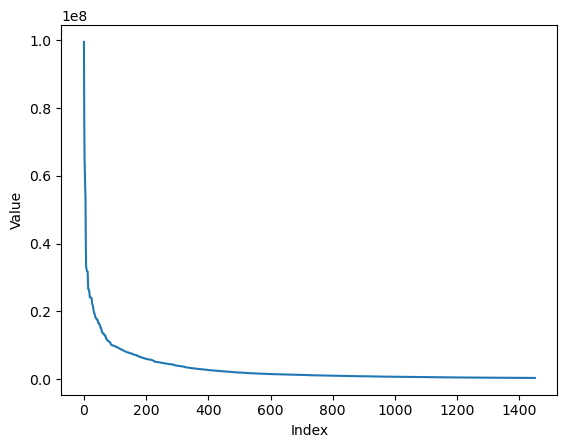

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
values = director_stats_sorted['total_popularity'].values

plt.plot(values[:int((len(director_stats_sorted)*0.05))])
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

Here we performed community detection with the Louvain-algorithm.

In [63]:
from Artist_Director_Graph.actor_director_functions import make_louvain_communities
import networkx as nx

cluster_labels,nodes, embeddings = make_louvain_communities(actors_director_graph, actors_director_graph)

Louvain detected 30 communities
The modularity: 0.4078
Number of communities detected: 30

Community sizes:
  Community 0: 5525 members
  Community 1: 4321 members
  Community 2: 3784 members
  Community 3: 3497 members
  Community 4: 2338 members
  Community 5: 1085 members
  Community 6: 781 members
  Community 7: 705 members
  Community 8: 693 members
  Community 9: 547 members


In [71]:
from Artist_Director_Graph.cluster_naming_llm import generate_name_for_clusters
from dotenv import load_dotenv
load_dotenv()   #Load the .env file containing the API key for the LLM

cluster_names = generate_name_for_clusters(nodes, cluster_labels, cache_path="cluster_names.json")
print(f"Name for cluster 0: {cluster_names[0]}")

Loaded 30 cluster names from cache: cluster_names.json
Name for cluster 0: Mixed B-Movie and Independent Film Actors


The next cell is needed for creating a 3D visualization of the graph: https://dh-anna.github.io/Social_Graph_Final_Project/
It only exports the graph in a gziped JSON format that is readable by our visualizer.

In [22]:
import json
import gzip

# Filter to most important nodes/edges
degree_dict = dict(actors_director_graph.degree())
top_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)[:1000]
subgraph = actors_director_graph.subgraph(top_nodes).copy()

# Create node to cluster mapping from Louvain results
node_to_cluster = {node: int(cluster) for node, cluster in zip(nodes, cluster_labels)}

# Determine node type based on graph structure and add cluster data:
# In this directed graph, edges go from actor -> director
# So: nodes with incoming edges are directors, nodes with only outgoing edges are actors
for node in subgraph.nodes():
    in_degree = subgraph.in_degree(node)
    out_degree = subgraph.out_degree(node)

    if in_degree > 0 and out_degree == 0:
        # Only receives edges = pure director
        subgraph.nodes[node]['type'] = 'director'
    elif in_degree == 0 and out_degree > 0:
        # Only sends edges = pure actor
        subgraph.nodes[node]['type'] = 'actor'
    elif in_degree > 0 and out_degree > 0:
        # Both = actor-director (classify based on which role dominates)
        # If more incoming than outgoing, they're primarily a director
        subgraph.nodes[node]['type'] = 'director' if in_degree >= out_degree else 'actor'
    else:
        # Isolated node (shouldn't happen in largest component)
        subgraph.nodes[node]['type'] = 'unknown'

    # Add cluster data
    if node in node_to_cluster:
        subgraph.nodes[node]['cluster'] = node_to_cluster[node]
    else:
        subgraph.nodes[node]['cluster'] = -1  # Unknown cluster

data = nx.node_link_data(subgraph, edges="links")
with gzip.open('../3d-visualization/public/graph.json.gz', 'wt') as f:
    json.dump(data, f, separators=(',', ':'))


Here we print some of the members from each community.

In [23]:
from Artist_Director_Graph.actor_director_functions import clusters_to_node, print_members_for_each_clusters

# Create a dictionary mapping cluster to nodes
cluster_to_nodes = clusters_to_node(nodes, cluster_labels)
# Print members of each cluster
print_members_for_each_clusters(cluster_to_nodes)


Cluster 0 (5525 members):
A Martinez, A. Blaine Miller, A. Dean Bell, A. Raven Cruz, A. Todd Smith, A.J. Briones, A.J. Mattioli, AJ Michalka, Aaliyah, Aaron Ashmore
... and 5515 more

Cluster 1 (4321 members):
A.D. Calvo, A.J. Bond, A.J. Cook, A.J. Kparr, A.T. White, Aaron Blaise, Aaron Fjellman, Aaron Fradkin, Aaron Harvey, Aaron Katz
... and 4311 more

Cluster 2 (3784 members):
50 Cent, A.J. Edwards, A.J. Langer, A.W. Vidmer, Aaron B. Koontz, Aaron Douglas, Aaron Eckhart, Aaron Fisher, Aaron J. Wiederspahn, Aaron Rottinghaus
... and 3774 more

Cluster 3 (3497 members):
Aadila Dosani, Aaron McCann, Aaron Paul, Aaron Taylor-Johnson, Aash Aaron, Abdul Latif Salazar, Abigail Blackmore, Abner Pastoll, Ace Bhatti, Ada Nicodemou
... and 3487 more

Cluster 4 (2338 members):
Abbas Fahdel, Abbas Kiarostami, Abdellatif Kechiche, Abderrahmane Sissako, Abril Zamora, Achero Mañas, Achim von Borries, Adam Bogen, Adam MacDonald, Adele Exarchopoulos
... and 2328 more

Cluster 5 (1085 members):
A.J. 

Here we list some basic statistics about the clusters

We can see that the nodes with the biggest degree centrality are all established directors.

In [24]:
# Get degree centrality for filtered graph
degree_centrality = nx.degree_centrality(actors_director_graph)
sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True)[:10]

[('Woody Allen', 0.01372402098039989),
 ('Steven Spielberg', 0.012619789407264267),
 ('Clint Eastwood', 0.010805694679970028),
 ('Steven Soderbergh', 0.010687384154276926),
 ('Michael Bay', 0.009780336790629807),
 ('Ridley Scott', 0.009701463106834405),
 ('Oliver Stone', 0.009307094687857396),
 ('Ron Howard', 0.00855779469180108),
 ('Eric Roberts', 0.008281736798517176),
 ('James Franco', 0.008281736798517176)]

For each cluster whe print out the members who have the highest node centrality.

In [25]:
from Artist_Director_Graph.actor_director_functions import find_top_n_members_of_each_cluster

# Find top n members by centrality in each cluster, this is just interesting fact
find_top_n_members_of_each_cluster(5, cluster_to_nodes,degree_centrality, actors_director_graph )


Cluster 0 - Top 5 most connected:
  Ron Howard (degree: 217)
  Eric Roberts (degree: 210)
  Robert Rodriguez (degree: 208)
  Quentin Tarantino (degree: 207)
  Danny Trejo (degree: 175)

Cluster 1 - Top 5 most connected:
  Woody Allen (degree: 348)
  Brett Ratner (degree: 208)
  Peter Farrelly (degree: 195)
  Garry Marshall (degree: 191)
  Steven Brill (degree: 185)

Cluster 2 - Top 5 most connected:
  Steven Spielberg (degree: 320)
  Clint Eastwood (degree: 274)
  Steven Soderbergh (degree: 271)
  Michael Bay (degree: 248)
  Oliver Stone (degree: 236)

Cluster 3 - Top 5 most connected:
  Ridley Scott (degree: 246)
  Chris Columbus (degree: 190)
  Tim Burton (degree: 179)
  J.J. Abrams (degree: 164)
  Kenneth Branagh (degree: 164)

Cluster 4 - Top 5 most connected:
  Gerard Depardieu (degree: 118)
  Neil Jordan (degree: 118)
  Liam Neeson (degree: 115)
  David Cronenberg (degree: 113)
  Udo Kier (degree: 108)

Cluster 5 - Top 5 most connected:
  Frank Welker (degree: 110)
  Fred Tatasc

Now we analyze which cluster contains directors with the highest node centrality.

In [26]:
from Artist_Director_Graph.actor_director_functions import calculate_member_centralities, \
    find_cluster_with_highest_avg_centrality

cluster_centralities = calculate_member_centralities(cluster_to_nodes, degree_centrality)

sorted_by_average_centrality = sorted( cluster_centralities.items(), key=lambda x: x[1]['avg_centrality'], reverse=True)

for rank, (cluster_id, data) in enumerate(sorted_by_average_centrality[:10], 1):
    print(f"\n{rank}. Cluster {cluster_id}:")
    print(f"   Avg centrality: {data['avg_centrality']:.6f}")
    print(f"   Size: {data['size']} members")


members_with_centrality = find_cluster_with_highest_avg_centrality(sorted_by_average_centrality, degree_centrality, actors_director_graph)




1. Cluster 2:
   Avg centrality: 0.000730
   Size: 3784 members

2. Cluster 1:
   Avg centrality: 0.000689
   Size: 4321 members

3. Cluster 3:
   Avg centrality: 0.000520
   Size: 3497 members

4. Cluster 19:
   Avg centrality: 0.000516
   Size: 33 members

5. Cluster 12:
   Avg centrality: 0.000434
   Size: 311 members

6. Cluster 5:
   Avg centrality: 0.000426
   Size: 1085 members

7. Cluster 15:
   Avg centrality: 0.000403
   Size: 134 members

8. Cluster 9:
   Avg centrality: 0.000399
   Size: 547 members

9. Cluster 6:
   Avg centrality: 0.000351
   Size: 781 members

10. Cluster 0:
   Avg centrality: 0.000343
   Size: 5525 members

Cluster 2 has the highest average centrality of 0.000730
Rank   Director or Actor                        Centrality      Degree    
1      Steven Spielberg                         0.012620        320       
2      Clint Eastwood                           0.010806        274       
3      Steven Soderbergh                        0.010687        271  

In [43]:
from Artist_Director_Graph.actor_director_functions import visualize_actor_director_graph

visualize_actor_director_graph(embeddings,cluster_labels, nodes )

We can also find people in the clusters with this function

In [28]:
from Artist_Director_Graph.actor_director_functions import find_person_cluster

# Find which cluster contains specific actors/directors

# Example usage
find_person_cluster("Lionel Barrymore", nodes, cluster_labels, cluster_to_nodes)
find_person_cluster("Tom Hanks", nodes, cluster_labels, cluster_to_nodes)

Lionel Barrymore not found (might have been filtered out)
Tom Hanks is in Cluster 2
Other members include: 50 Cent, A.J. Edwards, A.J. Langer, A.W. Vidmer, Aaron B. Koontz...


This is needed because we first used another director_popularity dataset, but it turned out to be not so good. After that we created the director_stats_sorted, but by that time we already used the term director_popularity everwhere and we did not want to change it.

In [29]:
director_popularity = director_stats_sorted

First we wanted to select the first few percentage of the directors as the "most popular directors". We made a cutoff for popular director at 400 as we discussed above.

In [30]:
from Artist_Director_Graph.actor_director_functions import calculate_popular_directors_for_each_cluster, print_popular_directors_in_each_cluster

# We find the most popular directors
n_popular = 400
popularity_threshold = director_popularity['total_popularity'].nlargest(n_popular).min()  #.quantile(0.75)
popular_directors = set(director_popularity[director_popularity['total_popularity'] >= popularity_threshold]['director'])


print(f"We select the first {len(popular_directors)} directors as popular directors. \n")

# Count popular directors in each cluster
cluster_popular_counts, cluster_popular_directors = calculate_popular_directors_for_each_cluster(cluster_to_nodes,popular_directors)

cluster_popular_directors_percentages= print_popular_directors_in_each_cluster(cluster_popular_counts, cluster_popular_directors, cluster_to_nodes)

We select the first 400 directors as popular directors. 

Cluster 0: 16 popular directors out of 5525 total members (0.3%)
  Examples: Brian Taylor, Darren Lynn Bousman, Eli Roth, Eric Bress, Frank Miller

Cluster 1: 117 popular directors out of 4321 total members (2.7%)
  Examples: Adam McKay, Adam Shankman, Andy Tennant, Ang Lee, Anne Fletcher

Cluster 2: 96 popular directors out of 3784 total members (2.5%)
  Examples: Alexander Payne, Allen Hughes, Andrew Davis, Andrew Niccol, Antoine Fuqua

Cluster 3: 89 popular directors out of 3497 total members (2.5%)
  Examples: Alan Taylor, Albert Hughes, Alejandro Amenábar, Alex Garland, Alexandre Aja

Cluster 4: 13 popular directors out of 2338 total members (0.6%)
  Examples: Alejandro G. Iñárritu, Andy Muschietti, Asghar Farhadi, David Cronenberg, J.A. Bayona

Cluster 5: 21 popular directors out of 1085 total members (1.9%)
  Examples: Adrian Molina, Andrew Stanton, Ash Brannon, Bob Peterson, Brad Bird

Cluster 6: 15 popular directors out

In [31]:
cluster_popular_directors_percentages

{np.int64(0): 0.28959276018099545,
 np.int64(1): 2.707706549409859,
 np.int64(2): 2.536997885835095,
 np.int64(3): 2.545038604518158,
 np.int64(4): 0.5560307955517536,
 np.int64(5): 1.935483870967742,
 np.int64(6): 1.9206145966709345,
 np.int64(7): 0.28368794326241137,
 np.int64(8): 0.1443001443001443,
 np.int64(9): 2.742230347349177,
 np.int64(10): 0.5758157389635317,
 np.int64(11): 0.5780346820809248,
 np.int64(12): 0.6430868167202572,
 np.int64(13): 0.7299270072992701,
 np.int64(14): 0.0,
 np.int64(15): 2.2388059701492535,
 np.int64(16): 0.0,
 np.int64(17): 0.0,
 np.int64(18): 0.0,
 np.int64(19): 0.0,
 np.int64(20): 0.0,
 np.int64(21): 0.0,
 np.int64(22): 0.0,
 np.int64(23): 0.0,
 np.int64(24): 0.0,
 np.int64(25): 0.0,
 np.int64(26): 0.0,
 np.int64(27): 0.0,
 np.int64(28): 0.0,
 np.int64(29): 0.0}

In [32]:
from Artist_Director_Graph.actor_director_functions import check_how_many_popular_directors_in_the_graph

# Check how many popular directors are actually in the graph nodes
check_how_many_popular_directors_in_the_graph(director_popularity, nodes)


  Found in graph: 15337
  NOT found in graph: 13686

Popular directors IN the graph:
  - Christopher Nolan
  - Quentin Tarantino
  - Steven Spielberg
  - Peter Jackson
  - David Fincher
  - Martin Scorsese
  - Ridley Scott
  - Frank Darabont
  - Robert Zemeckis
  - Clint Eastwood

Popular directors NOT in the graph (name mismatch or filtered out):
  - Mike Thurmeier
  - Kar-Wai Wong
  - Jee-woon Kim
  - Ki-duk Kim
  - Andrew Lau
  - Damián Szifron
  - Amole Gupte
  - Sang-ho Yeon
  - Alper Caglar
  - Galder Gaztelu-Urrutia



With this function we can list the actors in the cluster who worked with the popular directors.

In [33]:
from Artist_Director_Graph.actor_director_functions import list_actors_who_worked_with_popular_directors_in_cluster
# For each cluster, list actors who worked with popular directors
#list_actors_who_worked_with_popular_directors_in_cluster(cluster_to_nodes, cluster_popular_directors, actors_director_graph)

We have a Celebrity dataset which sort the most popular actors with a popularity sort. We check which cluster contains popular actors and we take the mean popularity of the popular actors.

In [34]:
from Artist_Director_Graph.actor_director_functions import clusters_by_average_actors_popularity

# Load celebrity data
df_celebrity = pd.read_csv('../Datasets/Celebrity.csv', index_col=0)

actor_popularity_map, cluster_avg_popularity, cluster_number_of_popular_actors = clusters_by_average_actors_popularity(df_celebrity, cluster_to_nodes)

Clusters ranked by average actor popularity:
Cluster 26: 44.79 from 1 actors.
This is the 0.3333333333333333 of the cluster.

Cluster 9: 43.68 from 76 actors.
This is the 0.13893967093235832 of the cluster.

Cluster 12: 39.47 from 46 actors.
This is the 0.14790996784565916 of the cluster.

Cluster 16: 38.78 from 6 actors.
This is the 0.046153846153846156 of the cluster.

Cluster 6: 38.38 from 103 actors.
This is the 0.13188220230473752 of the cluster.

Cluster 3: 38.01 from 655 actors.
This is the 0.18730340291678582 of the cluster.

Cluster 13: 37.80 from 13 actors.
This is the 0.04744525547445255 of the cluster.

Cluster 2: 37.06 from 879 actors.
This is the 0.2322938689217759 of the cluster.

Cluster 1: 36.92 from 1024 actors.
This is the 0.23698218005091415 of the cluster.

Cluster 11: 36.74 from 30 actors.
This is the 0.08670520231213873 of the cluster.

Cluster 4: 36.28 from 131 actors.
This is the 0.05603079555175364 of the cluster.

Cluster 19: 35.46 from 7 actors.
This is the 

Here we list the clusters with the highest degree centrality, the clusters where the percentage of directors who are popular are the higest, and the clusters where the average popularity of popular directors in the cluster are the highest. We can see that the clusters with the highest node centrality and, clusters with the highest director popularity percentage are really overlapping. This is not the case with the average popularity in the cluster, but this is also due to the fact that the average popularity of directors are not spread out that much, ranging only from approximately 30 to 59 from the lowest to the highest.

In [35]:
from Artist_Director_Graph.actor_director_functions import show_clusters_centrality_vs_popularity_table

show_clusters_centrality_vs_popularity_table([lst[0] for lst in sorted_by_average_centrality],sorted(cluster_popular_directors_percentages, key=cluster_popular_directors_percentages.get, reverse=True),sorted(cluster_avg_popularity, key=cluster_avg_popularity.get, reverse=True), 10 )

Degree centrality         Popular clusters     Average popularity clusters
--------------------------------------------------------------------------------
Cluster 2*                    Cluster 9*          Cluster 26                    
Cluster 1*                    Cluster 1*          Cluster 9*                   
Cluster 3*                    Cluster 3*          Cluster 12*                   
Cluster 19                     Cluster 2*          Cluster 16                    
Cluster 12*                    Cluster 15*          Cluster 6*                   
Cluster 5*                    Cluster 5*          Cluster 3*                   
Cluster 15*                    Cluster 6*          Cluster 13                    
Cluster 9*                    Cluster 13           Cluster 2*                   
Cluster 6*                    Cluster 12*          Cluster 1*                   
Cluster 0                     Cluster 11           Cluster 11                    


Sentiment analysis on movie's descriptions.

In [36]:
word_scores = {}
with open("labMIT-1.0.txt", 'r', encoding='utf-8') as f:
            next(f)
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) >= 3:
                    word = parts[0].lower()
                    happiness_score = float(parts[2])
                    word_scores[word] = happiness_score

In [37]:
import nltk

nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kostyalbalint/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/kostyalbalint/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/kostyalbalint/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/kostyalbalint/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

## Movies in Each Cluster

Now let's iterate through each cluster and collect all the movies associated with directors in those clusters.

In [38]:
from Artist_Director_Graph.cluster_movies_analysis import (
    collect_cluster_movies,
    get_unique_movies_per_cluster,
    print_cluster_movies_summary,
    print_cluster_movies_detail,
)

# Collect all movies for each cluster
cluster_movies = collect_cluster_movies(
    cluster_to_nodes=cluster_to_nodes,
    df_actors=df_actors,
    movie_directors_dict=movie_directors_dict,
    name_lookup=name_lookup
)

# Get unique movies (not actor-movie pairs)
cluster_unique_movies = get_unique_movies_per_cluster(cluster_movies)

# Print summary
summary = print_cluster_movies_summary(cluster_unique_movies, cluster_to_nodes, top_clusters=20)

Building director-to-movies mapping...
Found movies for 17170 directors

  Cluster  0:  15976 actor-movie entries,  4092 unique films, 2583 directors
  Cluster  1:  24000 actor-movie entries,  2761 unique films, 1502 directors
  Cluster  2:  23995 actor-movie entries,  3278 unique films, 1487 directors
  Cluster  3:  14223 actor-movie entries,  2665 unique films, 1337 directors
  Cluster  4:   6296 actor-movie entries,  2848 unique films, 1725 directors
  Cluster  5:   4041 actor-movie entries,   786 unique films,  573 directors
  Cluster  6:   1982 actor-movie entries,   460 unique films,  335 directors
  Cluster  7:   1845 actor-movie entries,   485 unique films,  361 directors
  Cluster  8:   1047 actor-movie entries,   734 unique films,  452 directors
  Cluster  9:   1251 actor-movie entries,   272 unique films,  219 directors
  Cluster 10:   1314 actor-movie entries,   611 unique films,  352 directors
  Cluster 11:    700 actor-movie entries,   389 unique films,  202 directors
  C

In [39]:
cluster_movies[28]

[{'director': 'Amar Adatia',
  'director_id': 'nm3720875',
  'film': 'Gangsters Gamblers Geezers',
  'film_id': 'tt2215211',
  'year': 2016,
  'actor': 'Rahul Kohli',
  'rating': 5.0,
  'votes': 743},
 {'director': 'Peter Peralta',
  'director_id': 'nm1408676',
  'film': 'Gangsters Gamblers Geezers',
  'film_id': 'tt2215211',
  'year': 2016,
  'actor': 'Rahul Kohli',
  'rating': 5.0,
  'votes': 743}]

In [40]:
len(cluster_unique_movies)

30

In [41]:
duck

NameError: name 'duck' is not defined

In [ ]:
'''
from Artist_Director_Graph.sentiment_analysis import calculate_sentiment_labmit

sentiment_scores_of_clusters = {}
movies_sentiment ={}
sentiment_scores_of_genres_in_clusters = {}

for cluster in cluster_unique_movies:
    genre_count = {}
    cluster_sentiment_score = 0
    sentiment_scores_of_genres_in_clusters[cluster] = {}
    for movie in cluster_movies[cluster]:
        film_id = movie['film_id']
        description = str(df_movies_imdb[df_movies_imdb.index == film_id]['description'])
        movies_sentiment[movie['film_id']] ={}

        sentiment = calculate_sentiment_labmit(description, word_scores)['labmit_mean']
        matching_rows = df_movies_imdb[df_movies_imdb.index == film_id]
        if not matching_rows.empty:
            movies_sentiment[film_id]['genres'] = df_movies_imdb[df_movies_imdb.index == film_id]['genre'].values[0].split(', ')
            movies_sentiment[film_id]['sentiment'] = sentiment
        cluster_sentiment_score += sentiment


        if len(matching_rows) > 0:
            for i in range(len(movies_sentiment[film_id]['genres'])):
                genre = movies_sentiment[film_id]['genres'][i]
                if genre not in sentiment_scores_of_genres_in_clusters[cluster]:
                    sentiment_scores_of_genres_in_clusters[cluster][genre] = 0
                sentiment_scores_of_genres_in_clusters[cluster][genre]+= movies_sentiment[film_id]['sentiment']
                if not genre in genre_count:
                    genre_count[genre] = 0
                genre_count[genre] +=1
    for key in sentiment_scores_of_genres_in_clusters[cluster]:
        sentiment_scores_of_genres_in_clusters[cluster][key] /= genre_count[key]

    if len(cluster_movies[cluster]) != 0:
        sentiment_scores_of_clusters[cluster] = cluster_sentiment_score / len(cluster_movies[cluster])
    else:
        sentiment_scores_of_clusters[cluster] = 0

for key, value in sentiment_scores_of_clusters.items():
    print(f"The sentiment of cluster {key} is {value}.")

'''

We save the sentiment scores into files, because calculating them takes nearly 15 minutes.

In [ ]:
'''
import json
sentiment_scores_of_clusters= {int(k): v for k, v in sentiment_scores_of_clusters.items()}
with open("sentiment_scores_of_clusters.json", "w") as f:
    json.dump(sentiment_scores_of_clusters, f, indent=4)

sentiment_scores_of_genres_in_clusters= {int(k): v for k, v in sentiment_scores_of_genres_in_clusters.items()}
with open("sentiment_scores_of_genres_in_clusters.json", "w") as f:
    json.dump(sentiment_scores_of_genres_in_clusters, f, indent=4)


'''

In [ ]:
import json
with open("sentiment_scores_of_clusters.json", "r") as f:
    sentiment_scores_of_clusters = json.load(f)

with open("sentiment_scores_of_genres_in_clusters.json", "r") as f:
    sentiment_scores_of_genres_in_clusters = json.load(f)

Here we have the average sentiment of each clusters.

In [ ]:
for key, value in sentiment_scores_of_clusters.items():
    print(f"The sentiment of cluster {key} is {value}.")

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
keys = list(sentiment_scores_of_clusters.keys())
values = list(sentiment_scores_of_clusters.values())

outlier_clusters = {k: v for k, v in sentiment_scores_of_clusters.items() if v < 4}
main_clusters = {k: v for k, v in sentiment_scores_of_clusters.items() if v >= 4}

main_keys = list(main_clusters.keys())
main_values = list(main_clusters.values())

fig, ax = plt.subplots(figsize=(14, 8))


colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(main_keys)))


bars = ax.bar(main_keys, main_values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_ylim(5.0, 5.7)


for bar, val in zip(bars, main_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

mean_val = np.mean(main_values)
ax.axhline(y=mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')

ax.set_xlabel('Community ID', fontsize=14)
ax.set_ylabel('Sentiment Score', fontsize=14)
ax.set_title('Average Sentiment Score of Communities using LabMT\n(Zoomed View: 5.0-5.7 Range)',
             fontsize=14, fontweight='bold')

ax.set_xticks(main_keys)
ax.tick_params(axis='both', labelsize=10)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)


ax.legend(fontsize=12, loc='upper right')

plt.tight_layout()
plt.savefig('sentiment_scores_by_communities_using_labmit.png', dpi=300, bbox_inches='tight')
plt.show()


WWe did a sentiment analysis with a Hugging Face pipeline, using the "sentiment-analysis" model. (https://huggingface.co/blog/sentiment-analysis-python) This models runs for nearly one and a half hour so we saved the outcome to the llm_sentiment_scores_of_clusters.npy.

In [ ]:
'''
from tqdm.auto import tqdm
from Artist_Director_Graph.sentiment_analysis import calculate_sentiment

llm_sentiment_scores_of_clusters = {}

for cluster in tqdm(cluster_unique_movies):
    # Collect all descriptions for this cluster
    descriptions = []
    for movie in cluster_movies[cluster]:
        description = str(df_movies_imdb[df_movies_imdb.index == movie['film_id']]['description'].values)
        if description and description != 'nan':
            descriptions.append(description)

    # Batch process all descriptions at once
    if descriptions:
        sentiment_results = calculate_sentiment(descriptions, batch_size=32)


        sentiment_scores = []
        for result in sentiment_results:
            if result:
                if result['label'] == 'POSITIVE':
                    sentiment_scores.append(result['score'])
                else:  # NEGATIVE
                    sentiment_scores.append(1 - result['score'])

        # Calculate average sentiment for the cluster
        if sentiment_scores:
            llm_sentiment_scores_of_clusters[cluster] = sum(sentiment_scores) / len(sentiment_scores)
        else:
            llm_sentiment_scores_of_clusters[cluster] = 0.5  # neutral default
    else:
        llm_sentiment_scores_of_clusters[cluster] = 0.5  # neutral default
'''

Here we load the precomputed llm sentiment scores from the of_clusters from the llm_sentiment_scores_of_clusters.npy file.

In [ ]:
#np.save("llm_sentiment_scores_of_clusters", llm_sentiment_scores_of_clusters)
_llm_sentiment_scores_of_clusters = np.load("llm_sentiment_scores_of_clusters.npy", allow_pickle=True).item()
print(_llm_sentiment_scores_of_clusters)

This is the barchart of the sentiment of each clusters using Hugging Face's pipeline. A sentiment is if it is close to 1 and negative if it is close to 0.

In [ ]:
from matplotlib import pyplot as plt

# Extract keys and values from the dictionary
keys = list(_llm_sentiment_scores_of_clusters.keys())
values = list(_llm_sentiment_scores_of_clusters.values())

# Create the bar chart
plt.bar(keys, values)
plt.xlabel('Cluster ID')
plt.ylabel('Sentiment score')
plt.title('Average sentiment score of the clusters from 0 to 1')
plt.savefig('sentiment_scores_by_clusters_using_hugging_face.png', dpi=300, bbox_inches='tight')
plt.show()

## Analyze the clusters by genre and production companies
Genre distribution across different clusters.

In [ ]:
from Artist_Director_Graph.cluster_attribute_analysis import (
    map_movies_to_attributes,
    analyze_attribute_distribution,
    get_specialization_score,
    compare_clusters_by_attribute,
    visualize_top_attributes_by_cluster,
    print_specialization_ranking,
    create_attribute_heatmap
)

# Map movies to genres
cluster_genres = map_movies_to_attributes(cluster_movies, df_movies_imdb, analysis_type='genre')

print(f"\nWe found genres for {len(cluster_genres)} clusters")

In [ ]:
# Analyze genre distribution for each cluster
cluster_genre_stats = analyze_attribute_distribution(
    cluster_genres,
    cluster_to_nodes,
    analysis_type='genre',
    top_n=10
)

high diversity score means the cluster works across many genres, while a low score indicates specialization in fewer genres.

Visualizations to better understand the genre patterns across clusters.

In [ ]:
# Visualize top genres for the largest clusters
fig_genres = visualize_top_attributes_by_cluster(cluster_genre_stats, analysis_type='genre', top_clusters=len(cluster_movies), top_items=5)

In [ ]:
# Calculate genre specialization scores and create heatmap
genre_specialization_scores = get_specialization_score(cluster_genres)
print_specialization_ranking(genre_specialization_scores, cluster_genres, analysis_type='genre', show_top_n=3)

# Create genre comparison matrix and heatmap
genre_matrix = compare_clusters_by_attribute(cluster_genres)
df_genre_heatmap = create_attribute_heatmap(genre_matrix, analysis_type='genre', top_n_clusters=len(cluster_movies), top_n_items=15)

In [ ]:
# Production Company Analysis
# Map movies to production companies
print("Mapping cluster movies to production companies...")
cluster_companies = map_movies_to_attributes(cluster_movies, df_movies_imdb, analysis_type='production_company')

print(f"\nMapped production companies for {len(cluster_companies)} clusters")

# Analyze production company distribution for each cluster
cluster_company_stats = analyze_attribute_distribution(
    cluster_companies,
    cluster_to_nodes,
    analysis_type='production_company',
    top_n=10
)

Visualizations to better understand the production company patterns across clusters.

In [ ]:
# Visualize top production companies for the largest clusters
fig_companies = visualize_top_attributes_by_cluster(cluster_company_stats, analysis_type='production_company', top_clusters=10, top_items=5)

# Calculate production company specialization scores and create heatmap
company_specialization_scores = get_specialization_score(cluster_companies)
print_specialization_ranking(company_specialization_scores, cluster_companies, analysis_type='production_company', show_top_n=3)

# Create production company comparison matrix and heatmap
company_matrix = compare_clusters_by_attribute(cluster_companies)
df_company_heatmap = create_attribute_heatmap(company_matrix, analysis_type='production_company', top_n_clusters=len(cluster_movies), top_n_items=40)

Time Era analysis

In [ ]:
from Artist_Director_Graph.cluster_time_period_analysis import (
    analyze_cluster_time_periods,
    categorize_by_era,
    print_time_period_summary,
    find_era_specialized_clusters,
    visualize_era_distribution,
    create_timeline_heatmap
)

In [ ]:
# Analyze time period statistics for each cluster
df_time_stats = analyze_cluster_time_periods(cluster_unique_movies, cluster_to_nodes)

# Categorize movies by era (Classic, Golden Age, Modern, Contemporary)
df_era = categorize_by_era(cluster_unique_movies, cluster_to_nodes)

In [ ]:
# Print comprehensive time period summary
print_time_period_summary(df_time_stats, df_era, top_n=20)

In [ ]:
# Find clusters that are specialized in specific eras (>60% of movies in one era)
specialized_clusters = find_era_specialized_clusters(df_era, threshold=60)

In [ ]:
# Create era distribution visualization (stacked bar chart)
fig_era = visualize_era_distribution(df_era, output_file='cluster_era_distribution.png', top_n=20)

In [ ]:
# Create timeline heatmap showing movie distribution by decade
fig_timeline = create_timeline_heatmap(cluster_unique_movies, output_file='cluster_timeline_heatmap.png', top_n=20)

## Sentiment Analysis on Movies of Popular Actors

In this section, we analyze the sentiment of movie descriptions for films featuring popular actors from the Celebrity.csv dataset. We try to find out whether popular actors has a specific sentiment of movies

In [ ]:

# Load celebrity data if not already loaded
if 'df_celebrity' not in globals():
    df_celebrity = pd.read_csv('../Datasets/Celebrity.csv', index_col=0)

# Load IMDb movies data if not already loaded  
if 'df_movies_imdb' not in globals():
    df_movies_imdb = pd.read_csv('../Datasets/IMDb movies.csv', index_col=0, low_memory=False)

# Load actor films data if not already loaded
if 'df_actors' not in globals():
    df_actors = pd.read_csv('../Datasets/IMDB/actorfilms.csv', low_memory=False)
    df_actors = df_actors[pd.to_numeric(df_actors['Year'], errors='coerce') >= 1990]

In [ ]:
# Select top celebrities for analysis (top 50 by popularity)
top_celebrities = df_celebrity.nlargest(500, 'popularity')
print(f"Analyzing top {len(top_celebrities)} celebrities by popularity")

celebrity_names = top_celebrities['name'].tolist()
actor_movies = df_actors[df_actors['Actor'].isin(celebrity_names)].copy()

print(f"Found {len(actor_movies)} movie entries for top celebrities")


df_movies_imdb_clean = df_movies_imdb[['title', 'description', 'avg_vote', 'year']].copy()
df_movies_imdb_clean = df_movies_imdb_clean.dropna(subset=['description'])

# Merge actor movies with movie descriptions
actor_movies_with_desc = actor_movies.merge(
    df_movies_imdb_clean,
    left_on='Film',
    right_on='title',
    how='inner'
)

print(f"Matched {len(actor_movies_with_desc)} movies with descriptions")
print(f"Unique movies: {actor_movies_with_desc['Film'].nunique()}")
actor_movies_with_desc.head()

In [ ]:
from Artist_Director_Graph.sentiment_analysis import calculate_sentiment

unique_movies = actor_movies_with_desc[['Film', 'description']].drop_duplicates(subset=['Film'])
print(f"Analyzing sentiment for {len(unique_movies)} unique movies")

descriptions = unique_movies['description'].tolist()
sentiment_results = calculate_sentiment(descriptions, batch_size=16)

# Add sentiment results to unique movies
unique_movies['sentiment_label'] = [r['label'] if r else None for r in sentiment_results]
unique_movies['sentiment_score'] = [r['score'] if r else None for r in sentiment_results]

unique_movies['sentiment_value'] = unique_movies.apply(
    lambda row: row['sentiment_score'] if row['sentiment_label'] == 'POSITIVE' else -row['sentiment_score'] if row['sentiment_label'] == 'NEGATIVE' else 0,
    axis=1
)

print(f"\nSentiment distribution:")
print(unique_movies['sentiment_label'].value_counts())
print(f"\nAverage sentiment score: {unique_movies['sentiment_value'].mean():.3f}")
unique_movies.head(10)

In [ ]:
actor_movies_sentiment = actor_movies_with_desc.merge(
    unique_movies[['Film', 'sentiment_label', 'sentiment_score', 'sentiment_value']],
    on='Film',
    how='left'
)

# Calculate average sentiment per actor
actor_sentiment_stats = actor_movies_sentiment.groupby('Actor').agg({
    'sentiment_value': ['mean', 'median', 'std', 'count'],
    'sentiment_label': lambda x: (x == 'POSITIVE').sum() / len(x) if len(x) > 0 else 0
}).round(3)

all_actor_sentiment_stats = actor_movies_sentiment.groupby('Actor').agg({
    'sentiment_value': ['mean', 'median', 'std', 'count'],
    'sentiment_label': lambda x: (x == 'POSITIVE').sum() / len(x) if len(x) > 0 else 0
}).round(3)

actor_sentiment_stats.columns = ['avg_sentiment', 'median_sentiment', 'std_sentiment', 'num_movies', 'positive_ratio']
actor_sentiment_stats = actor_sentiment_stats[actor_sentiment_stats['num_movies'] >= 3]  # Filter actors with at least 3 movies

all_actor_sentiment_stats.columns = ['avg_sentiment', 'median_sentiment', 'std_sentiment', 'num_movies', 'positive_ratio']
all_actor_sentiment_stats = actor_sentiment_stats[actor_sentiment_stats['num_movies'] >= 3]  # Filter actors with at least 3 movies

# Merge with celebrity data to get popularity
actor_sentiment_stats = actor_sentiment_stats.merge(
    top_celebrities[['name', 'popularity']],
    left_index=True,
    right_on='name',
    how='inner'
)

all_actor_sentiment_stats = all_actor_sentiment_stats.merge(
    top_celebrities[['name', 'popularity']],
    left_index=True,
    right_on='name',
    how='inner'
)




In [ ]:
top_20_actors = actor_sentiment_stats.nlargest(20, 'avg_sentiment')

plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top_20_actors)), top_20_actors['avg_sentiment'])


colors = ['green' if x > 0 else 'red' for x in top_20_actors['avg_sentiment']]
for bar, color in zip(bars, colors):
    bar.set_color(color)
    bar.set_alpha(0.7)

plt.yticks(range(len(top_20_actors)), top_20_actors['name'])
plt.xlabel('Average Sentiment Score')
plt.title('Top 20 Actors by Average Movie Sentiment Score')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    actor_sentiment_stats['popularity'],
    actor_sentiment_stats['avg_sentiment'],
    s=actor_sentiment_stats['num_movies'] * 10,
    alpha=0.6,
    c=actor_sentiment_stats['positive_ratio'],
    cmap='RdYlGn'
)

plt.xlabel('Actor Popularity')
plt.ylabel('Average Sentiment Score')
plt.title('Actor popularity and their average film sentiment\n(Size = Number of Movies, Color = Sentiment score)')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
plt.grid(True, alpha=0.3)


cbar = plt.colorbar(scatter)
cbar.set_label('Positive Movie Ratio')

top_popular = actor_sentiment_stats.nlargest(15, 'popularity')
for _, actor in top_popular.iterrows():
    plt.annotate(
        actor['name'],
        (actor['popularity'], actor['avg_sentiment']),
        fontsize=8,
        alpha=0.7,
        xytext=(5, 5),
        textcoords='offset points'
    )

top_sentiment = actor_sentiment_stats.nlargest(10, 'avg_sentiment')
for _, actor in top_sentiment.iterrows():
    if actor['name'] not in top_popular['name'].values:
        plt.annotate(
            actor['name'],
            (actor['popularity'], actor['avg_sentiment']),
            fontsize=8,
            alpha=0.7,
            xytext=(5, 5),
            textcoords='offset points'
        )

# Annotate actors with lowest sentiment scores
bottom_sentiment = actor_sentiment_stats.nsmallest(10, 'avg_sentiment')
for _, actor in bottom_sentiment.iterrows():
    if actor['name'] not in top_popular['name'].values:
        plt.annotate(
            actor['name'],
            (actor['popularity'], actor['avg_sentiment']),
            fontsize=8,
            alpha=0.7,
            xytext=(5, -10),
            textcoords='offset points'
        )


most_movies = actor_sentiment_stats.nlargest(10, 'num_movies')
for _, actor in most_movies.iterrows():
    already_labeled = (actor['name'] in top_popular['name'].values or
                       actor['name'] in top_sentiment['name'].values or
                       actor['name'] in bottom_sentiment['name'].values)
    if not already_labeled:
        plt.annotate(
            actor['name'],
            (actor['popularity'], actor['avg_sentiment']),
            fontsize=8,
            alpha=0.7,
            xytext=(-5, -10),
            textcoords='offset points'
        )

plt.tight_layout()
plt.savefig('actor_popularity_and_the_average_sentiment_score_of_their_films.png', dpi=300, bbox_inches='tight')
plt.show()


spearman_corr, p_value = stats.spearmanr(actor_sentiment_stats['popularity'], actor_sentiment_stats['avg_sentiment'])
print(f"\nSpearman correlation between popularity and average sentiment: {spearman_corr:.3f}")
print(f"P-value: {p_value:.4f}")

In [ ]:
spearman_corr, p_value = stats.spearmanr(all_actor_sentiment_stats['popularity'], all_actor_sentiment_stats['avg_sentiment'])
print(f"\nSpearman correlation between popularity and average sentiment: {spearman_corr:.3f}")
print(f"P-value: {p_value:.4f}")